<a href="https://colab.research.google.com/github/irzamtalat786-bit/day-1-python/blob/main/MUHAMMAD_IRZAM_TALAT_24__AI_091_EMPLOYEE_OPEN_ENDED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset loaded successfully
Dataset Shape: (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5 

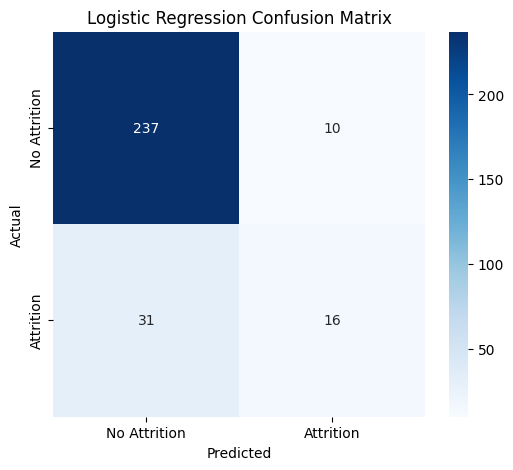

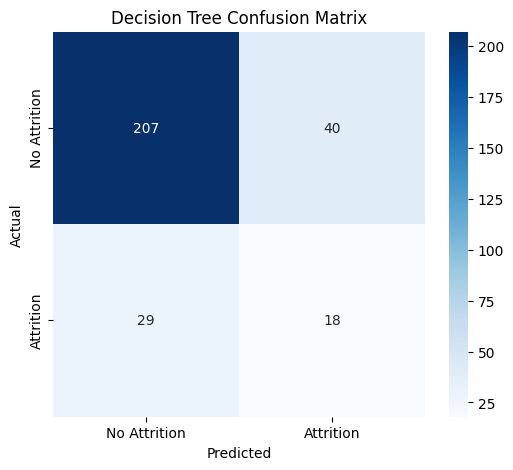

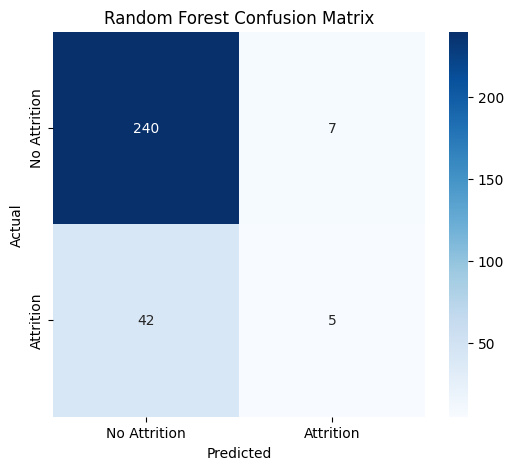

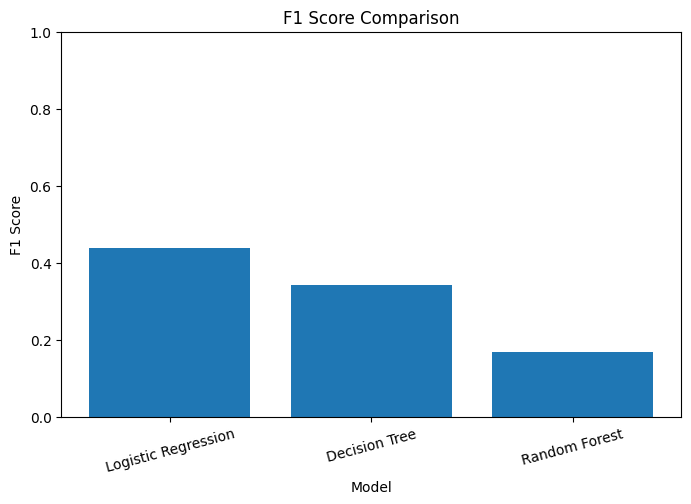


Top 10 Important Features
MonthlyIncome           0.072306
Age                     0.072260
TotalWorkingYears       0.053589
DailyRate               0.051670
HourlyRate              0.047866
DistanceFromHome        0.047793
MonthlyRate             0.047228
YearsAtCompany          0.044137
OverTime_Yes            0.037830
YearsWithCurrManager    0.035452
dtype: float64


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Lab 7 Open Ended Lab
# Project: Employee Attrition Analyzer
# Name: Muhammad Irzam Talat
# Roll No: 24F-AI-091

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load dataset

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

print("Dataset loaded successfully")
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

# Check missing values

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Handle missing values

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

# Convert Attrition into numbers

df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Remove unnecessary columns

drop_columns = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

df = df.drop(
    columns=[column for column in drop_columns if column in df.columns]
)

# One hot encoding

df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

# Separate features and target

X = df.drop(columns=["Attrition"])
y = df["Attrition"]

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale data for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create models

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train models

logistic_model.fit(X_train_scaled, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

# Predictions

logistic_pred = logistic_model.predict(X_test_scaled)

decision_tree_pred = decision_tree_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

# Model evaluation

models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

results = []

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction, zero_division=0)
    recall = recall_score(y_test, prediction, zero_division=0)
    f1 = f1_score(y_test, prediction, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("\nModel Evaluation Results")
print(results_df.round(4))

# Classification reports

for name, prediction in models.items():

    print("\n", name)
    print(
        classification_report(
            y_test,
            prediction,
            target_names=["No Attrition", "Attrition"],
            zero_division=0
        )
    )

# Confusion matrices

for name, prediction in models.items():

    cm = confusion_matrix(y_test, prediction)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Attrition", "Attrition"],
        yticklabels=["No Attrition", "Attrition"]
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# F1 Score comparison

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

# Random Forest feature importance

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
)

top_features = feature_importance.sort_values(
    ascending=False
).head(10)

print("\nTop 10 Important Features")
print(top_features)

# Feature importance graph

plt.figure(figsize=(10, 6))